In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")


In [5]:
df = pd.read_csv("Unemployment_in_India_Task2.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,Month,Year,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019,Pre-COVID
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019,Pre-COVID
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019,Pre-COVID
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019,Pre-COVID
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019,Pre-COVID


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 206
Number of columns: 10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   206 non-null    object 
 1   Date                                     206 non-null    object 
 2   Frequency                                206 non-null    object 
 3   Estimated Unemployment Rate (%)          206 non-null    float64
 4   Estimated Employed                       206 non-null    float64
 5   Estimated Labour Participation Rate (%)  206 non-null    float64
 6   Region.1                                 206 non-null    object 
 7   Month                                    206 non-null    object 
 8   Year                                     206 non-null    int64  
 9   Period                                   206 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 1

In [8]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'Month', 'Year', 'Period'],
      dtype='object')


In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year
count,206.000000,2.060000e+02,206.000000,206.000000
mean,11.739854,1.474196e+07,40.311796,2019.961165
std,8.923840,1.048323e+07,2.828347,0.193672
min,2.900000,3.000000e+06,30.000000,2019.000000
25%,5.500000,7.900000e+06,39.000000,2020.000000
50%,8.000000,1.227123e+07,40.500000,2020.000000
75%,15.000000,1.900000e+07,42.200000,2020.000000
max,47.000000,5.020000e+07,45.500000,2020.000000


In [10]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
Month                                      0
Year                                       0
Period                                     0
dtype: int64

In [11]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'Month', 'Year', 'Period'],
      dtype='object')


In [12]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (206, 10)


In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_10392\3129069064.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,Month,Year,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019,Pre-COVID
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019,Pre-COVID
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019,Pre-COVID
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019,Pre-COVID
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019,Pre-COVID


In [14]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
Month                                              object
Year                                                int64
Period                                             object
dtype: object

In [16]:
df['Region'] = df['Region'].str.strip()

In [17]:
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region.1,Month,Year,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019,Pre-COVID
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019,Pre-COVID
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019,Pre-COVID
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019,Pre-COVID
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019,Pre-COVID


In [18]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

region_avg

Region
Haryana           23.181818
Delhi             21.909091
Rajasthan         18.636364
Bihar             17.909091
Jharkhand         16.727273
Punjab            13.954545
Tamil Nadu        10.818182
Telangana         10.727273
Uttar Pradesh     10.545455
West Bengal        9.272727
Odisha             9.136364
Maharashtra        8.890909
Kerala             8.681818
Karnataka          8.600000
Madhya Pradesh     7.145455
Uttarakhand        6.709091
Andhra Pradesh     6.480000
Assam              5.817273
Name: Unemployment_Rate, dtype: float64

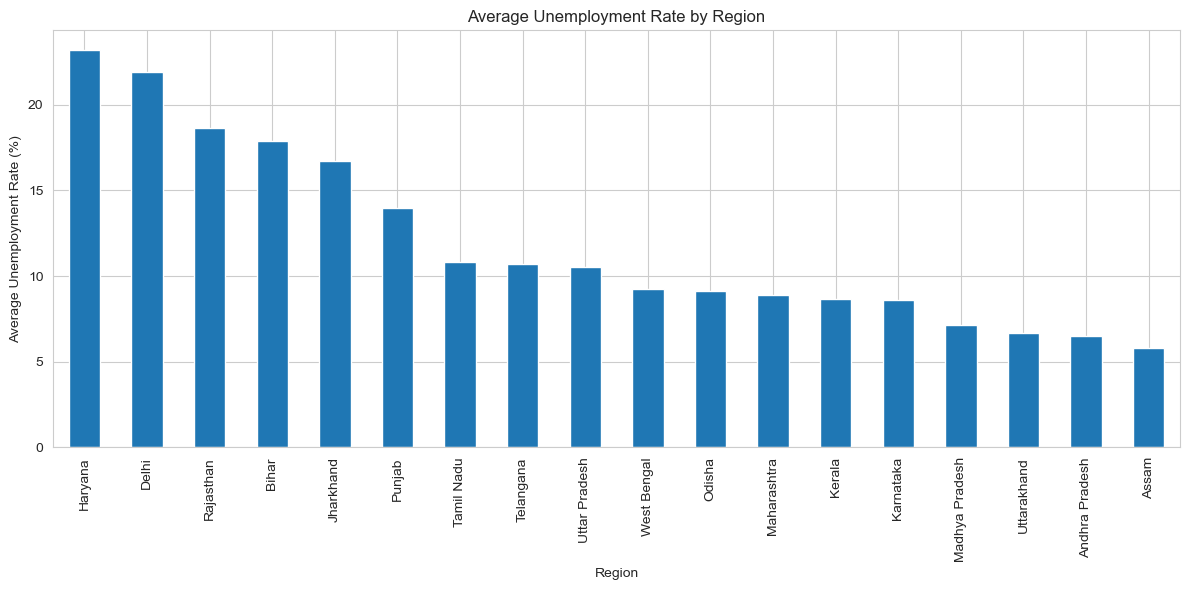

In [19]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
df['Month'] = df['Date'].dt.month_name()

df['Month_Number'] = df['Date'].dt.month

In [21]:
monthly_avg = df.groupby(
    ['Month_Number', 'Month']
)['Unemployment_Rate'].mean().sort_index()

monthly_avg

Month_Number  Month    
1             January       8.311667
2             February      8.135000
3             March         9.921667
4             April        28.409444
5             May          21.051579
6             June         11.571579
7             July         10.227895
8             August        9.261579
9             September     8.349474
10            October       7.584211
11            November      7.106842
12            December      4.500000
Name: Unemployment_Rate, dtype: float64

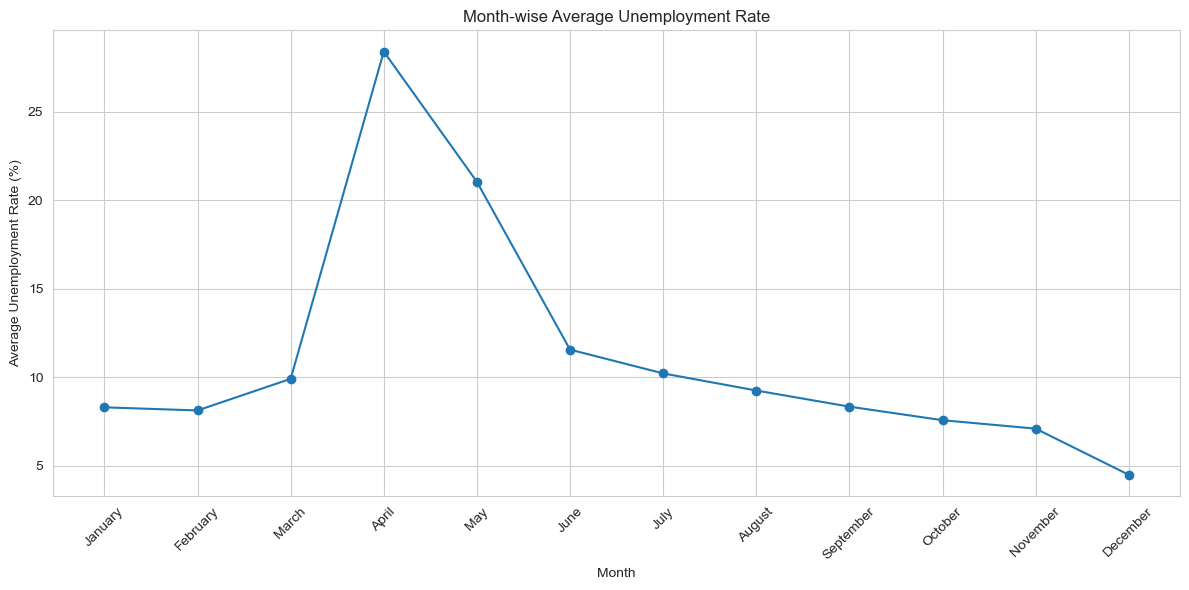

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index.get_level_values('Month'),
    monthly_avg.values,
    marker='o'
)

plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Delhi', 'Haryana',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu',
       'Telangana', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [25]:
selected_regions = ['Delhi', 'Maharashtra', 'Tamil Nadu']

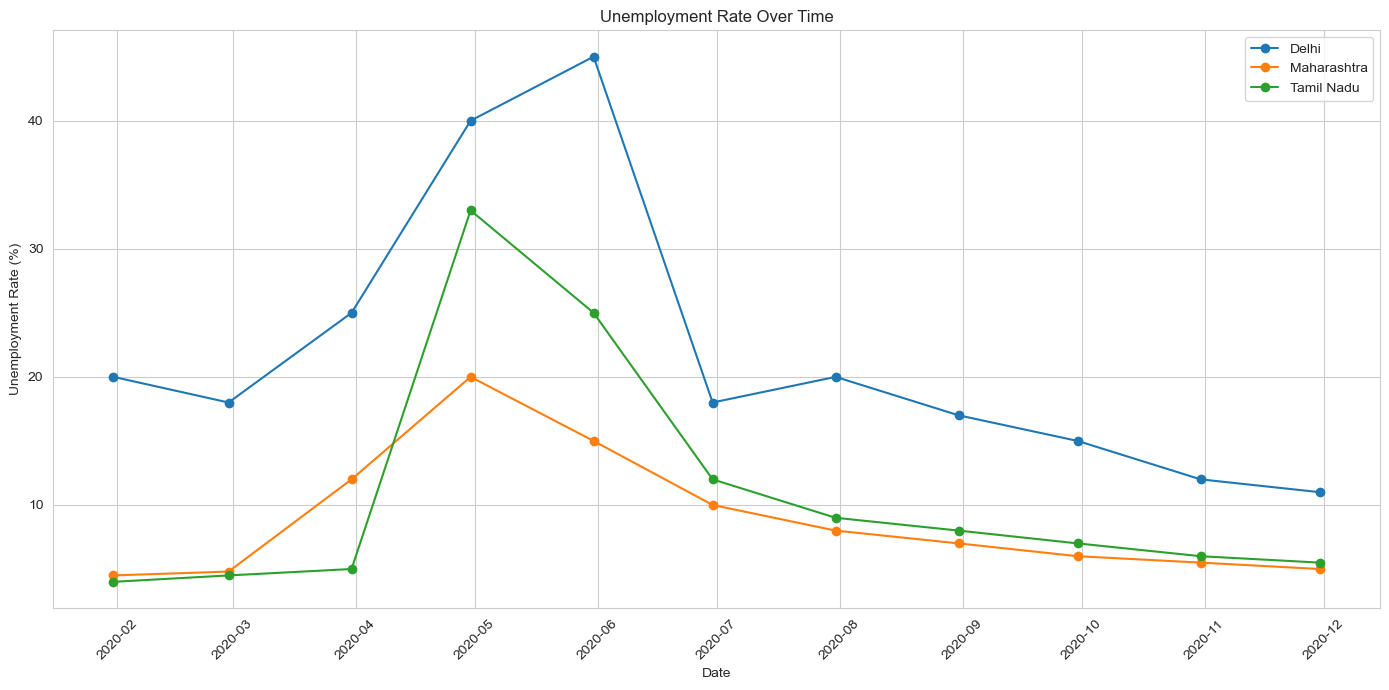

In [26]:
plt.figure(figsize=(14, 7))

for region in selected_regions:
    region_data = df[df['Region'] == region]

    plt.plot(
        region_data['Date'],
        region_data['Unemployment_Rate'],
        marker='o',
        label=region
    )

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
top_10 = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

Region
Haryana          23.181818
Delhi            21.909091
Rajasthan        18.636364
Bihar            17.909091
Jharkhand        16.727273
Punjab           13.954545
Tamil Nadu       10.818182
Telangana        10.727273
Uttar Pradesh    10.545455
West Bengal       9.272727
Name: Unemployment_Rate, dtype: float64

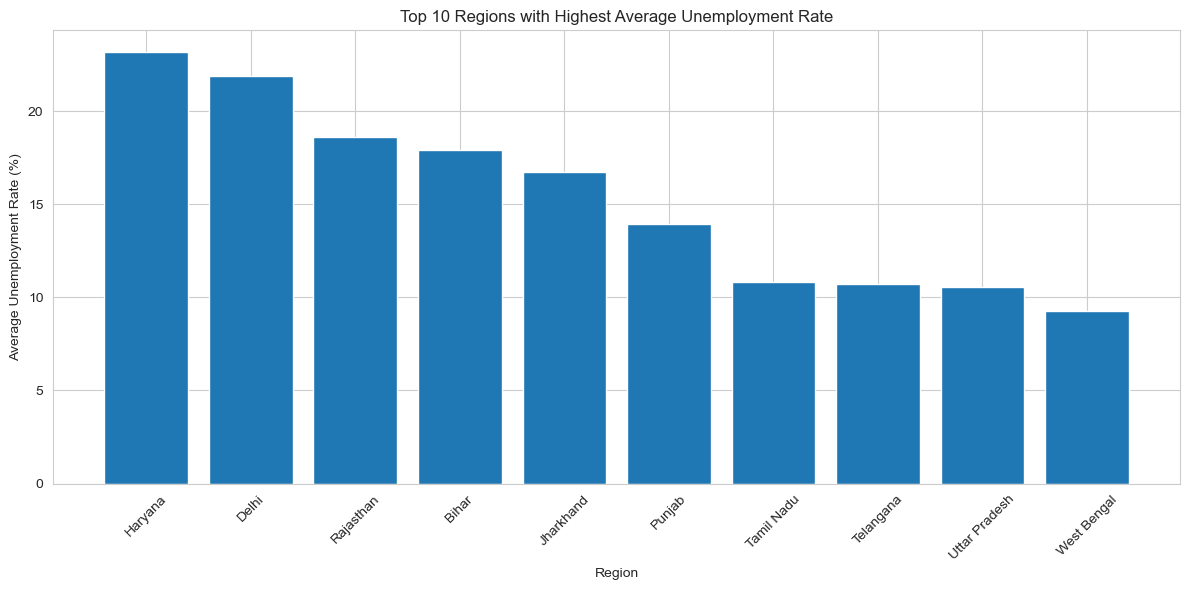

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(top_10.index, top_10.values)

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
correlation = df[
    ['Unemployment_Rate',
     'Employed',
     'Labour_Participation_Rate']
].corr()

correlation

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.000000,-0.190062,-0.591600
Employed,-0.190062,1.000000,-0.076832
Labour_Participation_Rate,-0.591600,-0.076832,1.000000


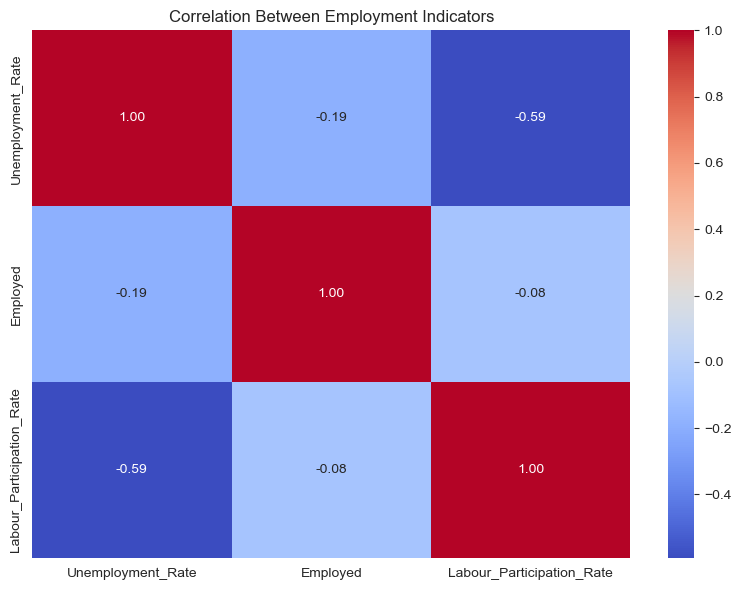

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

In [31]:
covid_date = pd.Timestamp('2020-03-01')

df['Period'] = np.where(
    df['Date'] < covid_date,
    'Pre-COVID',
    'Post-COVID'
)

df[['Date', 'Period']].head()

,Date,Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


In [32]:
period_avg = df.groupby('Period')['Unemployment_Rate'].mean()

period_avg


Period
Post-COVID    12.903086
Pre-COVID      7.457045
Name: Unemployment_Rate, dtype: float64

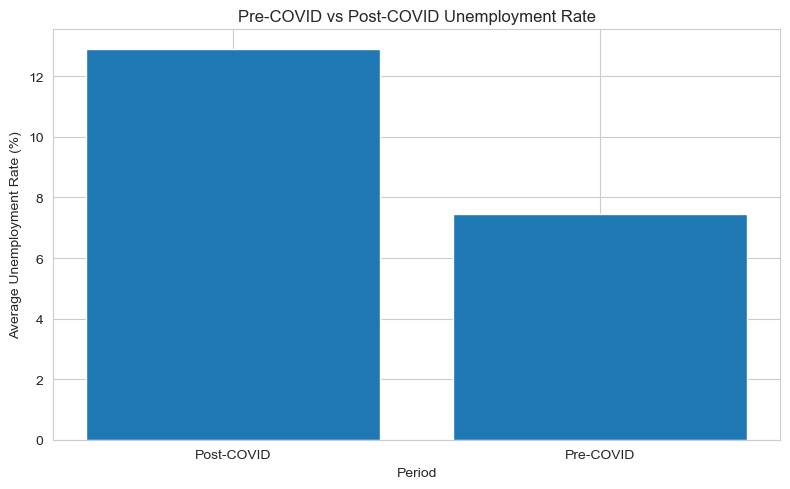

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(period_avg.index, period_avg.values)

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

In [34]:
period_comparison = df.groupby('Period')[
    ['Unemployment_Rate',
     'Employed',
     'Labour_Participation_Rate']
].mean()

period_comparison

,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Post-COVID,12.903086,1.468564e+07,39.856543
Pre-COVID,7.457045,1.494931e+07,41.987955


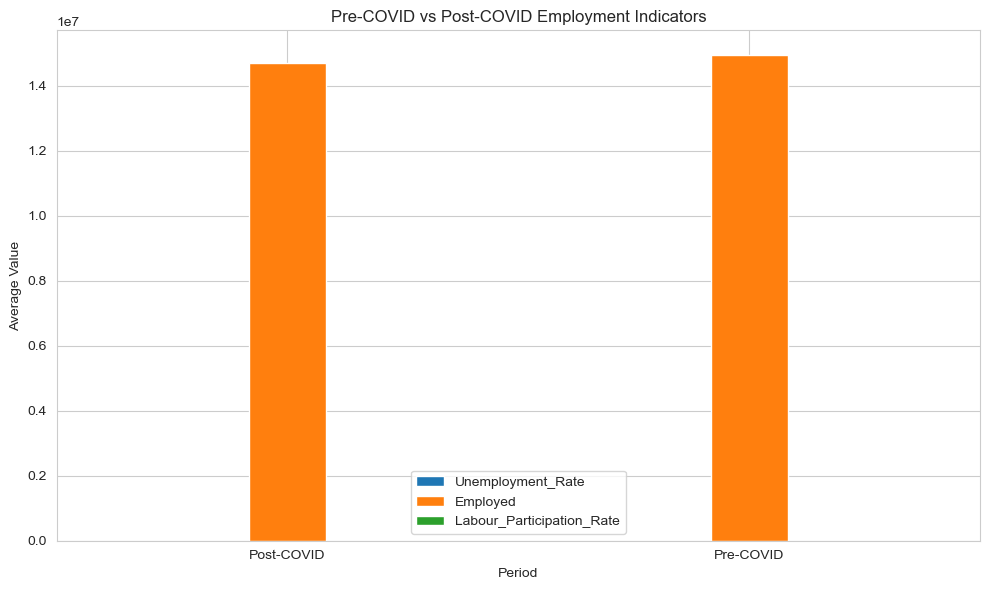

In [35]:
period_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Pre-COVID vs Post-COVID Employment Indicators')
plt.xlabel('Period')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
pre = period_comparison.loc['Pre-COVID']
post = period_comparison.loc['Post-COVID']

percentage_change = ((post - pre) / pre) * 100

percentage_change

Unemployment_Rate            73.032155
Employed                     -1.763731
Labour_Participation_Rate    -5.076245
dtype: float64

In [41]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Region.1', 'Month', 'Year', 'Period', 'Month_Number']


In [42]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg

KeyError: 'Column not found: Estimated Unemployment Rate (%)'

In [43]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Region.1', 'Month', 'Year', 'Period', 'Month_Number']


In [44]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean()

region_avg

Region
Andhra Pradesh     6.480000
Assam              5.817273
Bihar             17.909091
Delhi             21.909091
Haryana           23.181818
Jharkhand         16.727273
Karnataka          8.600000
Kerala             8.681818
Madhya Pradesh     7.145455
Maharashtra        8.890909
Odisha             9.136364
Punjab            13.954545
Rajasthan         18.636364
Tamil Nadu        10.818182
Telangana         10.727273
Uttar Pradesh     10.545455
Uttarakhand        6.709091
West Bengal        9.272727
Name: Unemployment_Rate, dtype: float64

In [45]:
region_avg = region_avg.sort_values(ascending=False)

region_avg

Region
Haryana           23.181818
Delhi             21.909091
Rajasthan         18.636364
Bihar             17.909091
Jharkhand         16.727273
Punjab            13.954545
Tamil Nadu        10.818182
Telangana         10.727273
Uttar Pradesh     10.545455
West Bengal        9.272727
Odisha             9.136364
Maharashtra        8.890909
Kerala             8.681818
Karnataka          8.600000
Madhya Pradesh     7.145455
Uttarakhand        6.709091
Andhra Pradesh     6.480000
Assam              5.817273
Name: Unemployment_Rate, dtype: float64

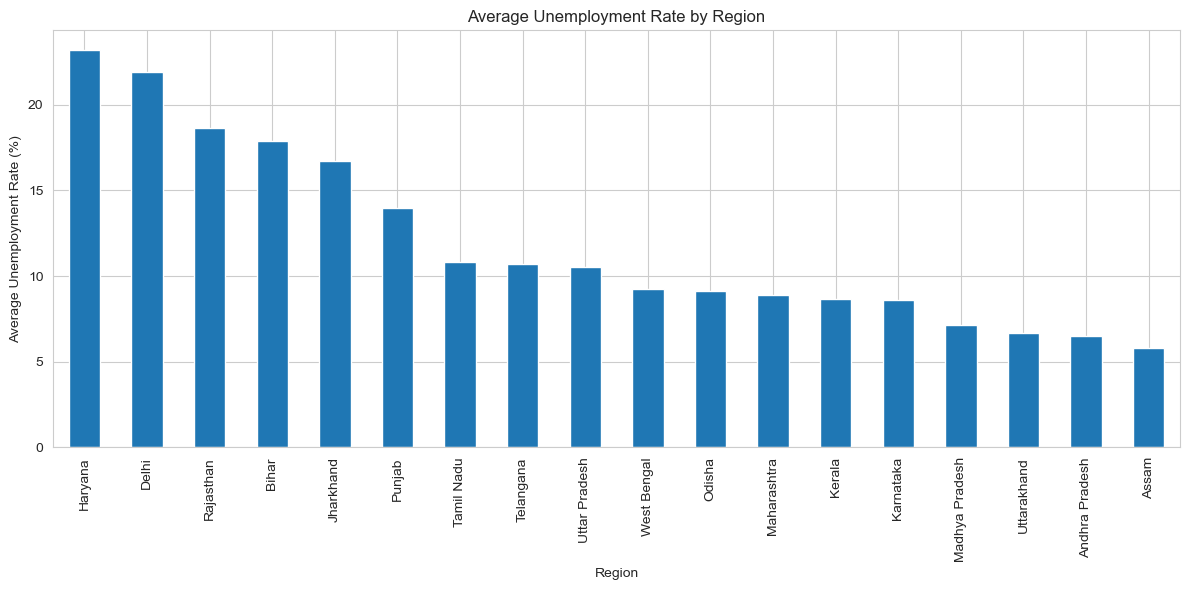

In [46]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows that unemployment rates vary across different regions of India. Some regions have higher average unemployment rates than others, indicating differences in employment opportunities and labour-market conditions.

In [47]:
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean()

monthly_avg

Month
April        28.409444
August        9.261579
December      4.500000
February      8.135000
January       8.311667
July         10.227895
June         11.571579
March         9.921667
May          21.051579
November      7.106842
October       7.584211
September     8.349474
Name: Unemployment_Rate, dtype: float64

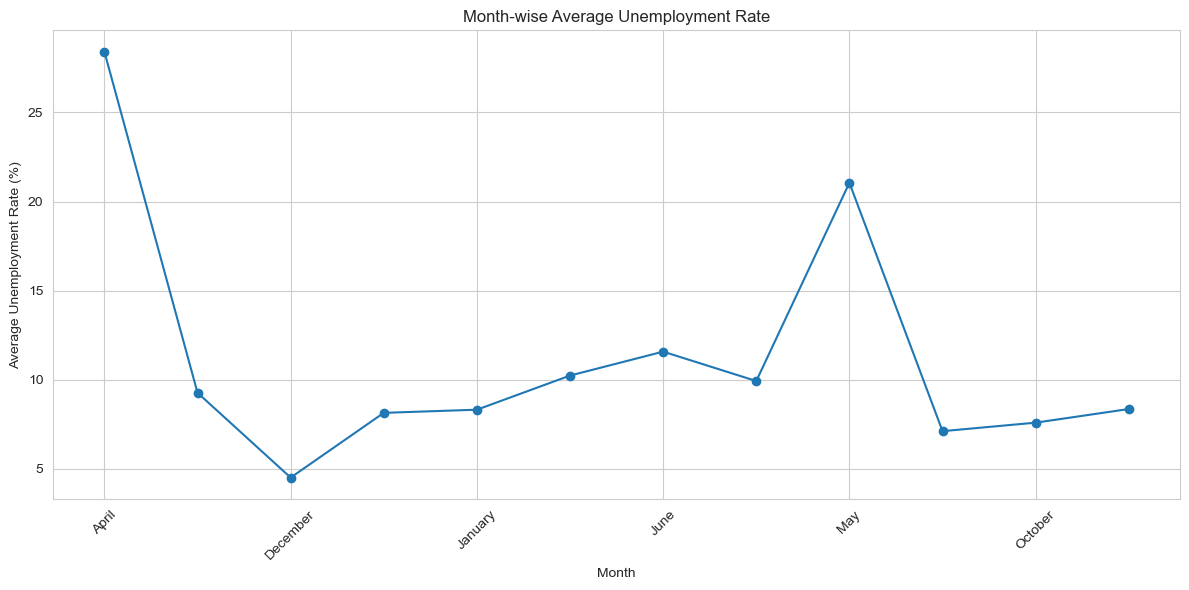

In [48]:
plt.figure(figsize=(12, 6))

monthly_avg.plot(kind='line', marker='o')

plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

In [50]:
monthly_avg = df.groupby(
    'Month',
    observed=False
)['Unemployment_Rate'].mean()

monthly_avg

Month
January       8.311667
February      8.135000
March         9.921667
April        28.409444
May          21.051579
June         11.571579
July         10.227895
August        9.261579
September     8.349474
October       7.584211
November      7.106842
December      4.500000
Name: Unemployment_Rate, dtype: float64

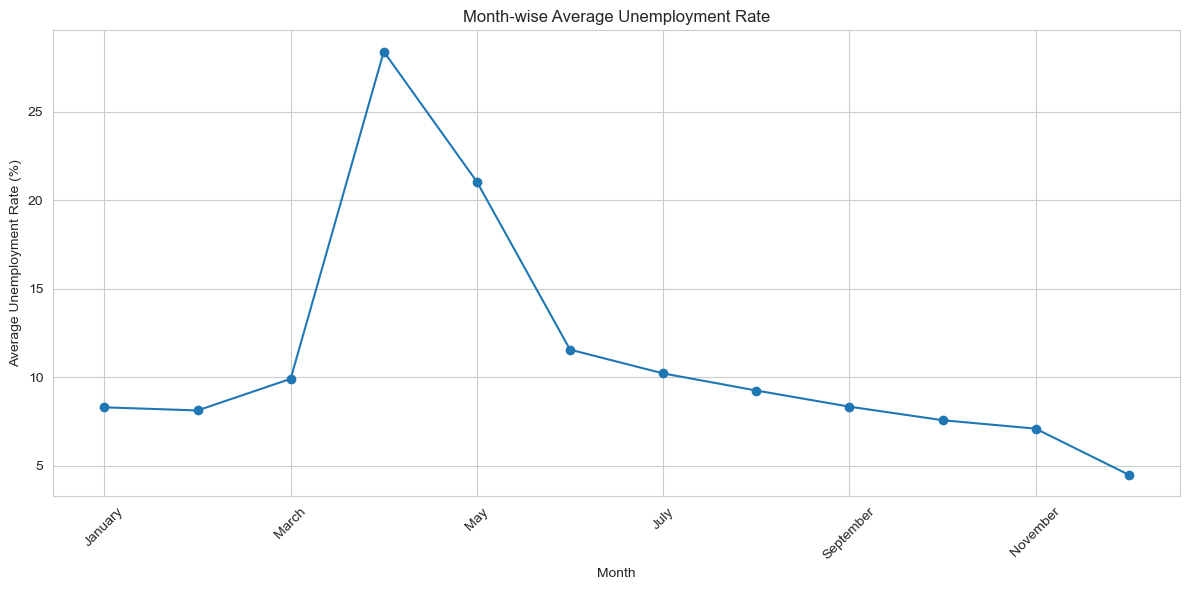

In [51]:
plt.figure(figsize=(12, 6))

monthly_avg.plot(kind='line', marker='o')

plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly trend shows fluctuations in unemployment rates across different months. The unemployment rate increased significantly during the COVID-19 period, reflecting the effect of lockdowns and restrictions on economic activities.

In [52]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Delhi', 'Haryana',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu',
       'Telangana', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [53]:
selected_regions = ['Delhi', 'Maharashtra', 'Tamil Nadu']

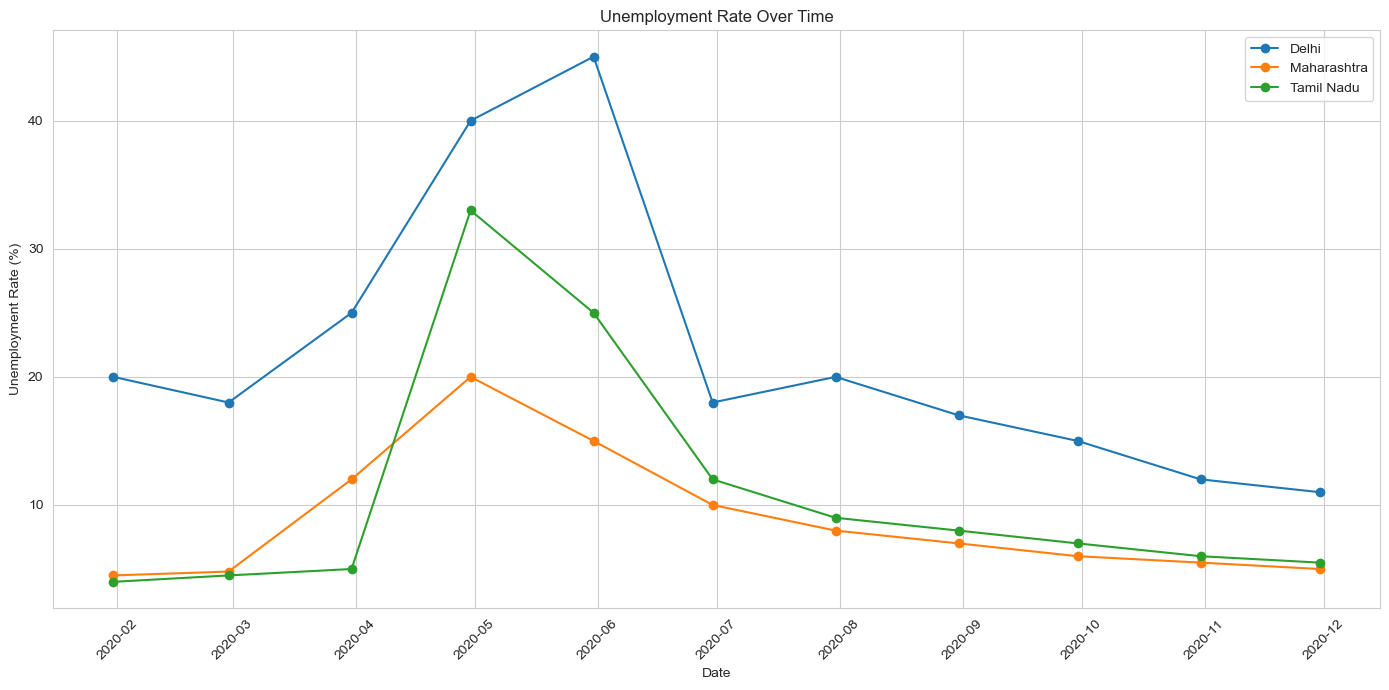

In [54]:
plt.figure(figsize=(14, 7))

for region in selected_regions:
    region_data = df[df['Region'] == region]
    
    plt.plot(
        region_data['Date'],
        region_data['Unemployment_Rate'],
        marker='o',
        label=region
    )

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The time-series chart shows changes in unemployment rates over time for Delhi, Maharashtra and Tamil Nadu. A significant increase can be observed during the COVID-19 lockdown period, followed by a gradual decline as economic activities resumed.

In [55]:
top_10 = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

Region
Haryana          23.181818
Delhi            21.909091
Rajasthan        18.636364
Bihar            17.909091
Jharkhand        16.727273
Punjab           13.954545
Tamil Nadu       10.818182
Telangana        10.727273
Uttar Pradesh    10.545455
West Bengal       9.272727
Name: Unemployment_Rate, dtype: float64

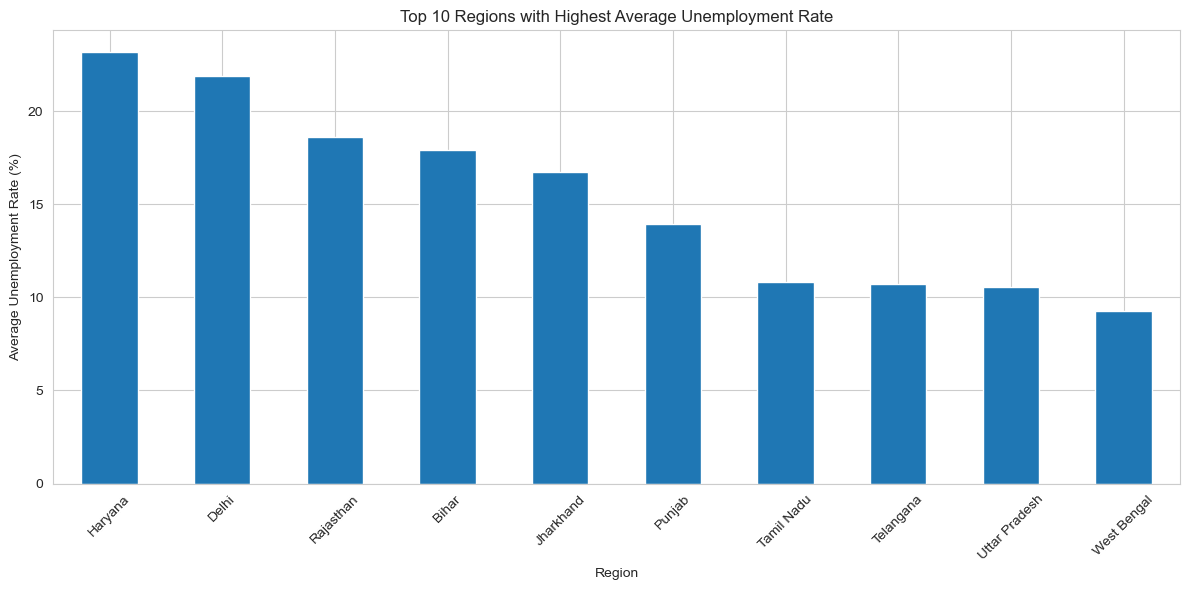

In [56]:
plt.figure(figsize=(12, 6))

top_10.plot(kind='bar')

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The chart shows the top 10 regions with the highest average unemployment rates. The results indicate that unemployment was not evenly distributed across India, with some regions experiencing considerably higher unemployment than others.

In [57]:
correlation = df[
    [
        'Unemployment_Rate',
        'Employed',
        'Labour_Participation_Rate'
    ]
].corr()

correlation

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.000000,-0.190062,-0.591600
Employed,-0.190062,1.000000,-0.076832
Labour_Participation_Rate,-0.591600,-0.076832,1.000000


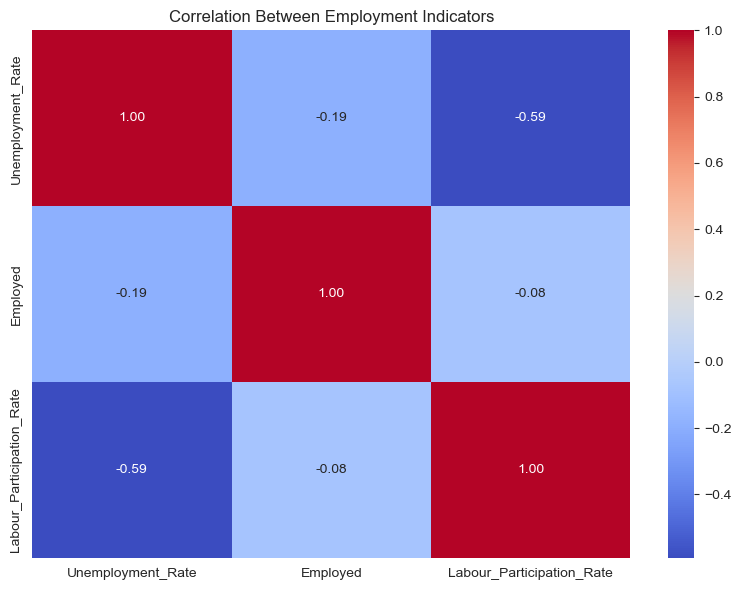

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

### Observation

The heatmap shows the correlation between unemployment, employment and labour participation. Positive values indicate that two variables tend to increase together, while negative values indicate an inverse relationship. Correlation represents association between variables and does not necessarily imply causation.

In [59]:
covid_date = pd.Timestamp('2020-03-01')

df['Period'] = np.where(
    df['Date'] < covid_date,
    'Pre-COVID',
    'Post-COVID'
)

In [60]:
df[['Date', 'Period']].head(20)

,Date,Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID
5,2019-10-31,Pre-COVID
6,2019-11-30,Pre-COVID
7,2019-12-31,Pre-COVID
8,2020-01-31,Pre-COVID
9,2020-02-29,Pre-COVID


In [61]:
period_avg = df.groupby('Period')['Unemployment_Rate'].mean()

period_avg

Period
Post-COVID    12.903086
Pre-COVID      7.457045
Name: Unemployment_Rate, dtype: float64

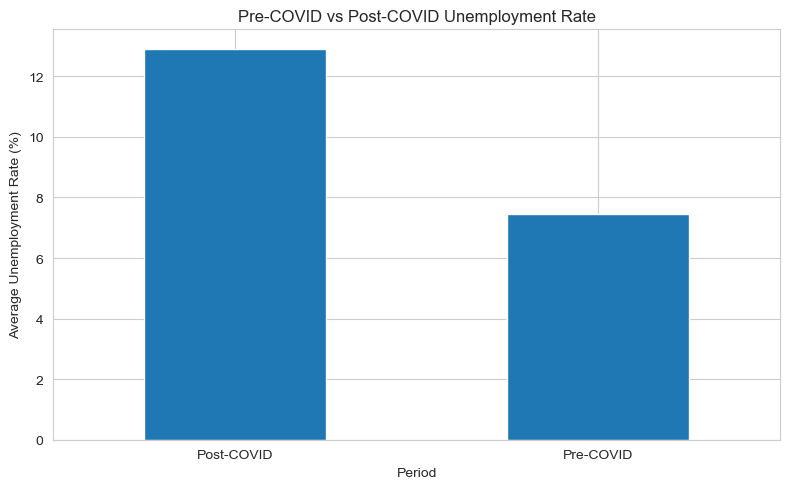

In [62]:
plt.figure(figsize=(8, 5))

period_avg.plot(kind='bar')

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The comparison between the pre-COVID and post-COVID periods shows a change in unemployment conditions. The COVID-19 pandemic and associated lockdowns disrupted businesses and employment activities, resulting in increased unemployment during several months of 2020.

In [63]:
period_comparison = df.groupby('Period')[
    [
        'Unemployment_Rate',
        'Employed',
        'Labour_Participation_Rate'
    ]
].mean()

period_comparison

,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Post-COVID,12.903086,1.468564e+07,39.856543
Pre-COVID,7.457045,1.494931e+07,41.987955


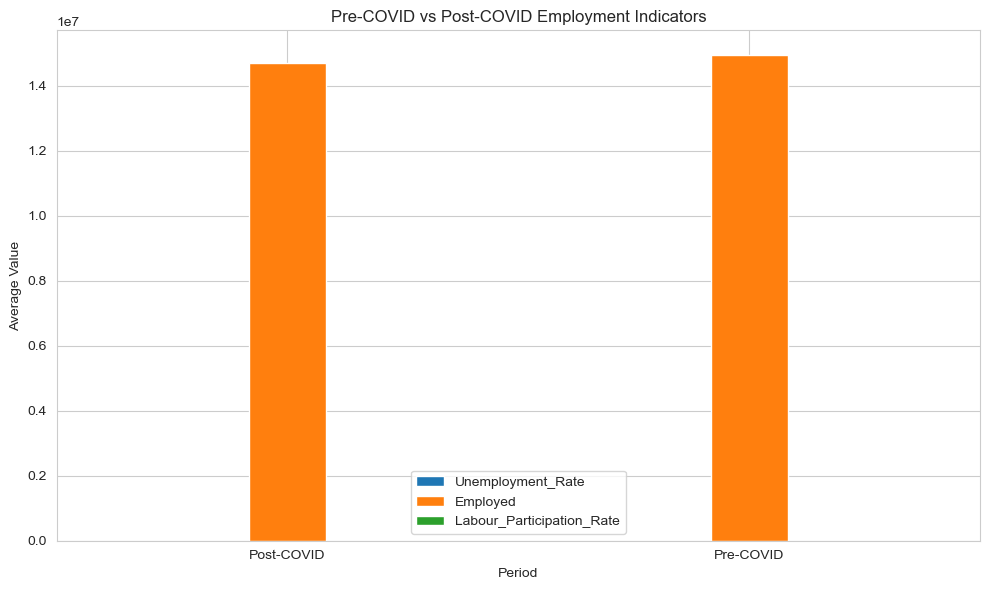

In [64]:
period_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Pre-COVID vs Post-COVID Employment Indicators')
plt.xlabel('Period')
plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
pre = period_comparison.loc['Pre-COVID']
post = period_comparison.loc['Post-COVID']

percentage_change = ((post - pre) / pre) * 100

percentage_change

Unemployment_Rate            73.032155
Employed                     -1.763731
Labour_Participation_Rate    -5.076245
dtype: float64

# Key Findings

1. Unemployment rates vary significantly across different regions of India.

2. The monthly analysis shows that unemployment changes over time.

3. The time-series analysis shows a noticeable increase in unemployment around the COVID-19 lockdown period.

4. The top 10 analysis identifies the regions with the highest average unemployment rates.

5. The correlation heatmap shows relationships between unemployment, employment and labour participation.

6. The Pre-COVID and Post-COVID comparison shows changes in India's labour-market conditions.

7. COVID-19 had a significant impact on employment and unemployment during 2020.

# Conclusion

The Unemployment Analysis project was conducted using Python, pandas, Matplotlib and Seaborn to understand unemployment trends in India.

The analysis examined regional unemployment rates, monthly trends, time-series patterns and the relationship between unemployment, employment and labour participation.

The results show significant differences in unemployment across regions. The time-series analysis also highlights the impact of the COVID-19 pandemic, particularly during the lockdown period in 2020.

The comparison between Pre-COVID and Post-COVID periods provides a clear view of how unemployment and other employment indicators changed during the pandemic.

Overall, exploratory data analysis provides useful insights into regional and temporal unemployment patterns and helps understand the impact of major economic events such as COVID-19.